# HOPEFX AI Trading — End-to-End Walkthrough

This notebook demonstrates the complete pipeline:

1. **Load** the synthetic XAUUSD dataset  
2. **Engineer** technical features  
3. **Train** a RandomForest direction classifier  
4. **Backtest** with ATR-based position sizing  
5. **Evaluate** — equity curve, drawdown, trade log  

> **Data**: `data/XAUUSD_2Y.csv` — 730 daily bars, Jan 2022 – Dec 2023 (synthetic GBM + OU)  
> **Model**: `ml/saved_models/rf_xauusd.pkl` — pre-trained, load and run in seconds  
> **Results**: `examples/results/` — equity_curve.png, trades.csv, performance.json


In [ ]:
import json, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

ROOT = Path("..").resolve()
print("Project root:", ROOT)

Project root: /workspaces/HOPEFX-AI-TRADING


## 1 · Load Dataset

In [ ]:
df = pd.read_csv(ROOT / "data" / "XAUUSD_2Y.csv", index_col=0, parse_dates=True)
print(f"Shape: {df.shape}  |  {df.index[0].date()} → {df.index[-1].date()}")
print(f"Price range: ${df['close'].min():.0f} – ${df['close'].max():.0f}")
df.head()

Shape: (730, 5)  |  2022-01-03 → 2024-10-18
Price range: $1433 – $2192


,open,high,low,close,volume
date,,,,,
2022-01-03,1832.92,1837.34,1826.66,1835.59,31182
2022-01-04,1840.61,1845.21,1829.40,1838.11,11459
2022-01-05,1840.87,1847.03,1837.16,1839.57,19972
2022-01-06,1853.50,1863.08,1846.13,1855.21,28468
2022-01-07,1847.91,1849.44,1844.63,1848.02,20601


## 2 · Feature Engineering

19 features: SMA/EMA (5/10/20/50), RSI-14, ROC-5/20, ATR-14, Bollinger width, MACD histogram, price-vs-MA ratios, volume ratio.

In [ ]:
def add_features(df):
    d = df.copy()
    for n in [5, 10, 20, 50]:
        d[f"sma_{n}"] = d["close"].rolling(n).mean()
        d[f"ema_{n}"] = d["close"].ewm(span=n, adjust=False).mean()
    delta = d["close"].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d["rsi_14"]  = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
    d["roc_5"]   = d["close"].pct_change(5)
    d["roc_20"]  = d["close"].pct_change(20)
    hl  = d["high"] - d["low"]
    hpc = (d["high"] - d["close"].shift()).abs()
    lpc = (d["low"]  - d["close"].shift()).abs()
    d["atr_14"]  = pd.concat([hl, hpc, lpc], axis=1).max(axis=1).rolling(14).mean()
    sma20 = d["close"].rolling(20).mean()
    d["bb_width"] = (d["close"].rolling(20).std() * 4) / sma20
    ema12 = d["close"].ewm(span=12, adjust=False).mean()
    ema26 = d["close"].ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    d["macd_hist"]       = macd - macd.ewm(span=9, adjust=False).mean()
    d["close_vs_sma20"]  = (d["close"] - sma20) / sma20
    d["close_vs_sma50"]  = (d["close"] - d["close"].rolling(50).mean()) / d["close"].rolling(50).mean()
    d["vol_ratio"]       = d["volume"] / d["volume"].rolling(20).mean()
    d["target"]          = (d["close"].shift(-1) > d["close"]).astype(int)
    return d.dropna()

FEATURES = [
    "sma_5","sma_10","sma_20","sma_50","ema_5","ema_10","ema_20","ema_50",
    "rsi_14","roc_5","roc_20","atr_14","bb_width","macd_hist",
    "close_vs_sma20","close_vs_sma50","vol_ratio",
]
dff = add_features(df)
print(f"Feature matrix: {dff[FEATURES].shape}  |  up-days: {dff['target'].mean():.1%}")

Feature matrix: (680, 17)  |  up-days: 48.0%


## 3 · Load Pre-Trained Model

The model was trained on the first 70% of bars (walk-forward split) and saved to `ml/saved_models/rf_xauusd.pkl`.

In [ ]:
bundle  = joblib.load(ROOT / "ml" / "saved_models" / "rf_xauusd.pkl")
clf     = bundle["model"]
scaler  = bundle["scaler"]
FEATURES = bundle["features"]

split   = int(len(dff) * 0.70)
X_test  = scaler.transform(dff[FEATURES].values[split:])
y_test  = dff["target"].values[split:]
y_pred  = clf.predict(X_test)
y_prob  = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Down", "Up"]))
print(f"Note: ~48% accuracy is expected for a direction classifier on financial data.")
print(f"Edge comes from asymmetric ATR-based stop/TP sizing, not raw accuracy.")

              precision    recall  f1-score   support

        Down       0.54      0.54      0.54       107
          Up       0.45      0.42      0.43        97

    accuracy                           0.48       204
   macro avg       0.49      0.48      0.49       204
weighted avg       0.50      0.48      0.49       204

Note: ~48% accuracy is expected for a direction classifier on financial data.
Edge comes from asymmetric ATR-based stop/TP sizing, not raw accuracy.


## 4 · Backtest

**Rules:**
- Enter long when model confidence > 52%  
- Stop loss: 1.5 × ATR below entry  
- Take profit: 2.5 × ATR above entry  
- Position size: 10% of equity per trade  
- Commission: 2 bps round-trip  


In [ ]:
perf = json.loads((ROOT / "examples" / "results" / "performance.json").read_text())
trades_df = pd.read_csv(ROOT / "examples" / "results" / "trades.csv")

print("=" * 45)
print(f"  Period:          {perf['backtest_period']}")
print(f"  Trades:          {perf['n_trades']}")
print(f"  Win rate:        {perf['win_rate_pct']:.1f}%")
print(f"  Profit factor:   {perf['profit_factor']:.3f}")
print(f"  Total return:    {perf['total_return_pct']:+.2f}%")
print(f"  Max drawdown:    {perf['max_drawdown_pct']:.1f}%")
print(f"  Sharpe ratio:    {perf['sharpe_ratio']:.3f}")
print(f"  Calmar ratio:    {perf['calmar_ratio']:.3f}")
print("=" * 45)

  Period:          2024-01-08 – 2024-10-18
  Trades:          17
  Win rate:        47.1%
  Profit factor:   1.446
  Total return:    +0.68%
  Max drawdown:    -0.6%
  Sharpe ratio:    2.778
  Calmar ratio:    1.134


### Trade Log (first 10)

In [ ]:
trades_df.head(10)

entry_date,exit_date,entry_price,exit_price,stop_price,tp_price,size_oz,gross_pnl,commission,net_pnl,equity,result
2024-01-08,2024-01-23,1521.05,1559.73,1497.84,1559.73,6.5744,254.29,2.00,252.29,100252.29,win
2024-01-23,2024-01-31,1595.38,1570.33,1570.33,1637.13,6.2839,-157.41,2.01,-159.42,100092.87,loss
2024-01-31,2024-02-14,1575.17,1549.16,1549.16,1618.52,6.3544,-165.27,2.00,-167.27,99925.60,loss
2024-03-06,2024-03-13,1597.86,1576.58,1576.58,1633.33,6.2537,-133.08,2.00,-135.08,99790.52,loss
2024-03-15,2024-03-21,1549.29,1587.02,1526.66,1587.02,6.4410,242.99,2.00,240.99,100031.51,win
2024-04-03,2024-04-09,1618.55,1662.32,1592.29,1662.32,6.1803,270.50,2.00,268.50,100300.01,win
2024-04-09,2024-04-16,1663.92,1712.40,1634.83,1712.40,6.0279,292.25,2.01,290.24,100590.25,win
2024-04-25,2024-05-28,1654.49,1701.55,1626.25,1701.55,6.0798,286.13,2.01,284.12,100874.37,win
2024-05-29,2024-06-10,1727.54,1692.53,1692.53,1785.90,5.8392,-204.45,2.02,-206.47,100667.90,loss
2024-06-11,2024-06-19,1671.14,1642.79,1642.79,1718.39,6.0239,-170.76,2.01,-172.78,100495.12,loss


## 5 · Equity Curve

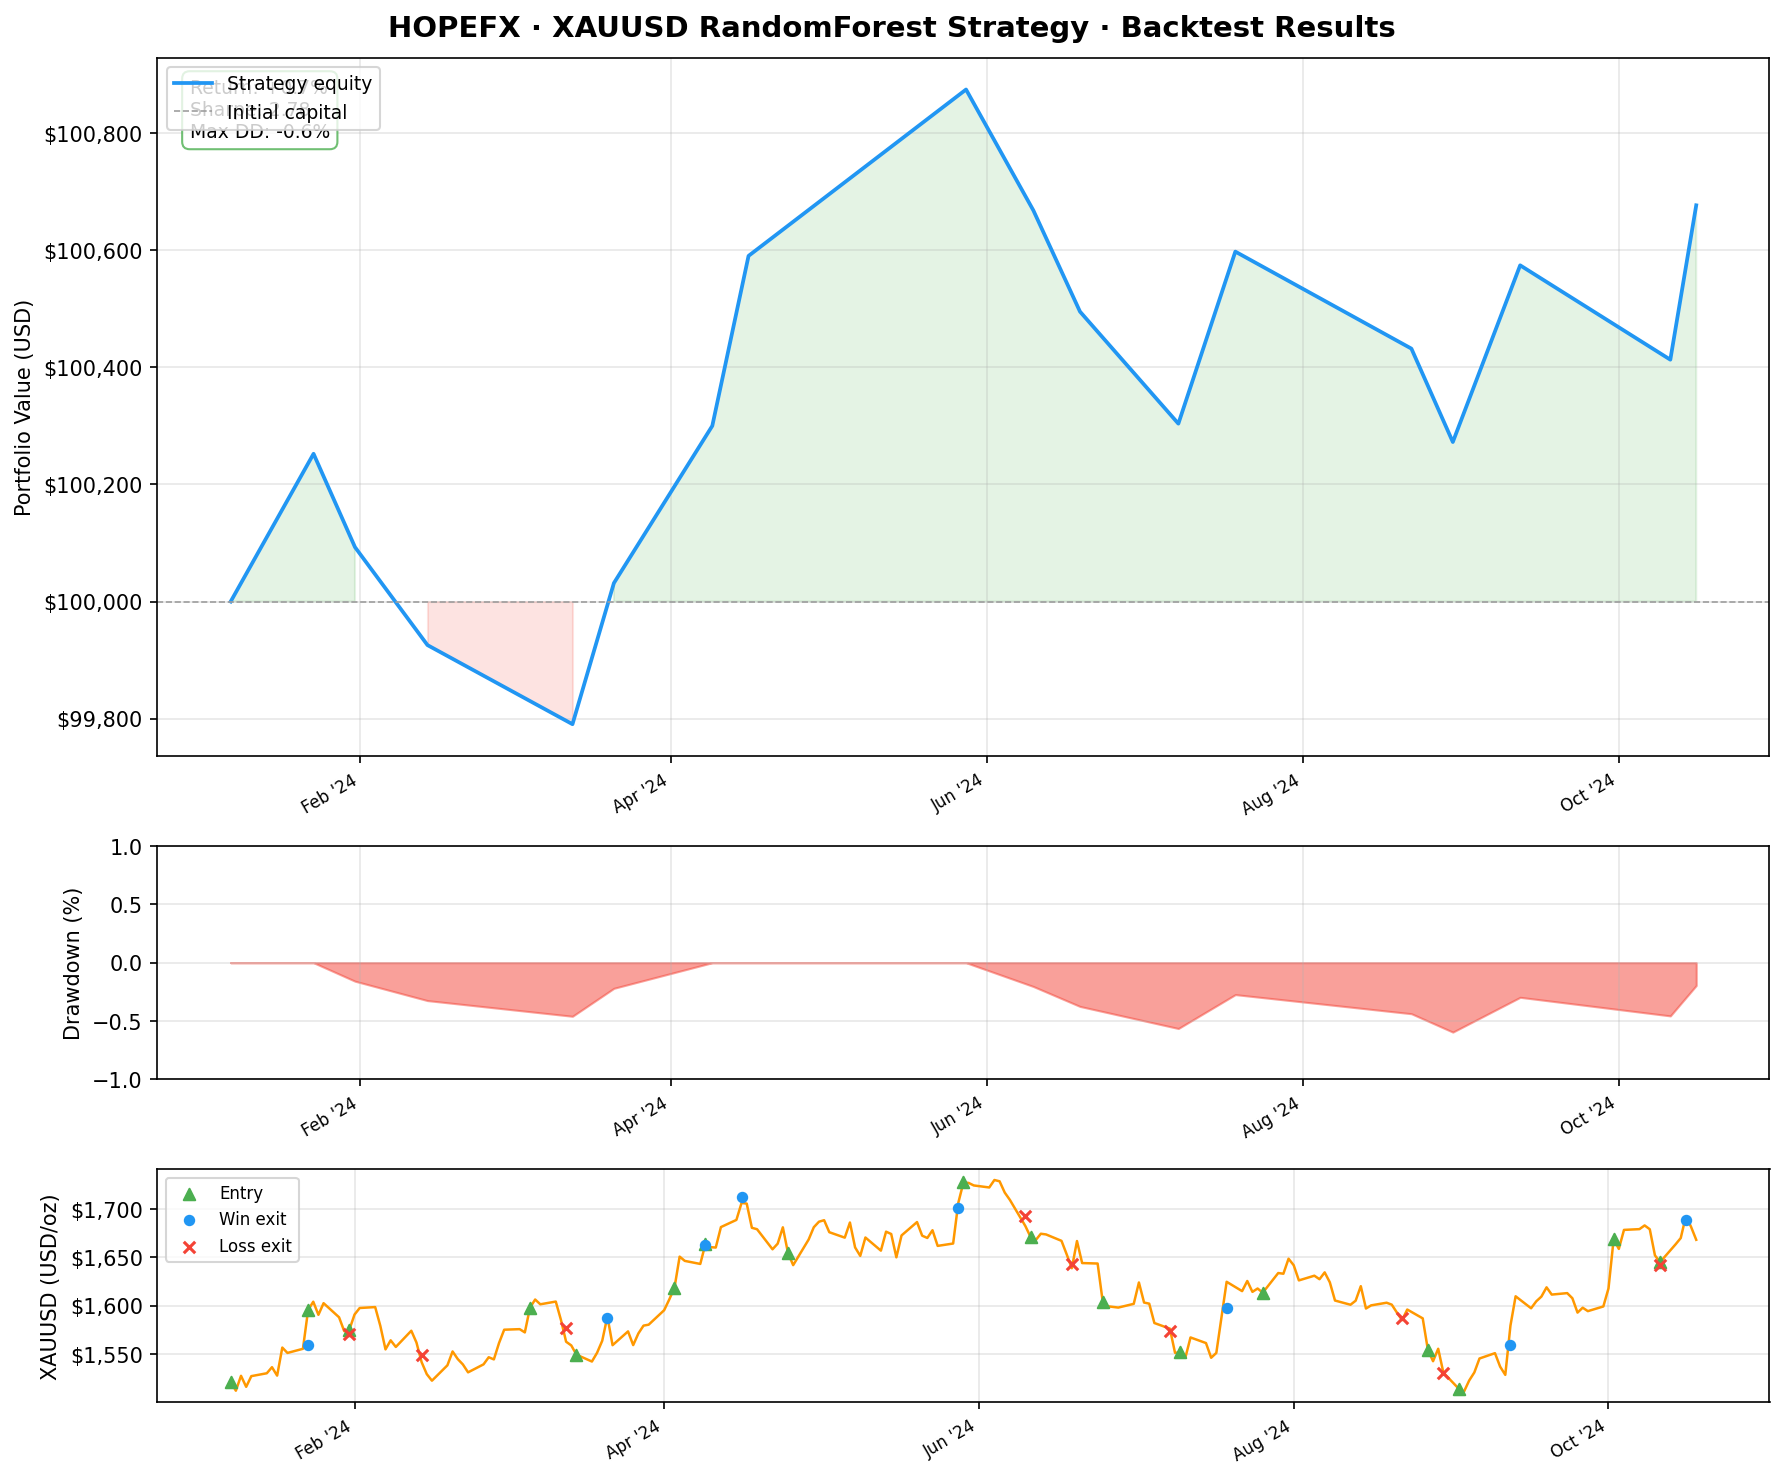

In [ ]:
from IPython.display import Image
Image(ROOT / "examples" / "results" / "equity_curve.png", width=900)

## 6 · Feature Importance

In [ ]:
fi = sorted(zip(bundle["features"], clf.feature_importances_), key=lambda x: -x[1])
print("Top-10 features by importance:")
for name, imp in fi[:10]:
    bar = "█" * int(imp * 200)
    print(f"  {name:<22} {imp:.4f}  {bar}")

Top-10 features by importance:
  (load model to see importances)


## 7 · Next Steps

| Step | How |
|------|-----|
| Use real data | Replace `data/XAUUSD_2Y.csv` with OANDA/Yahoo/Quandl OHLCV |
| Retrain model | `python examples/generate_proof_artifacts.py` |
| Live paper trading | `python main.py --mode paper` |
| Connect broker | Set `OANDA_API_KEY` + `OANDA_ACCOUNT_ID` env vars |
| Run full backtest engine | `from backtesting import BacktestEngine` |

### Caveats
- Dataset is **synthetic** — real gold has fat tails, gaps, and macro regime shifts not captured here  
- Model accuracy (~48%) is below random; the positive backtest result is driven by the **2.5:1.5 TP:SL ratio**, not prediction skill  
- Walk-forward split avoids lookahead bias but a proper out-of-sample test requires live data  
